# PathMNIST data import

This code imports the image data set used in this project. It also imports some of the standard libraries that you are likely to need and plots a couple of examples of the image data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(2) # this makes it run better on elab
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [2]:
# this allows pytorch to use a GPU, if one is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Below we load in the data from elab - I've also included a command below (commented out) to load in a local version in case you wish to work on a local machine. 

In [ ]:
import os
import os.path
data = np.load(os.path.expanduser('~') + '/datasets/Assignment1Data.npz')

In [4]:
data = np.load('./Assignment1Data.npz')

In [5]:
data.files

['train_images', 'train_labels', 'test_images', 'test_labels']

Once the data have been loaded, assign each of the training, validation and test sets to their own array

In [6]:
train_data = data['train_images']
train_labels = data['train_labels']
test_data = data['test_images']
test_labels = data['test_labels']

In [7]:
label_dict = {
            0: "adipose",
            1: "lymphocytes",
            2: "normal colon mucosa",
            3: "cancer-associated stroma",
            4: "colorectal adenocarcinoma epithelium"
        }

**View an example image and its label**
note that each image is of size 28x28x3. The 28 corresponds to the height and width of the image in pixels. There are 3 channels, corresponding to the amount of Red, Green, and Blue in each pixel. 

In [8]:
label1 = train_labels[0]
label_dict[label1[0]]

'adipose'

Text(0.5, 0.01, 'adipose')

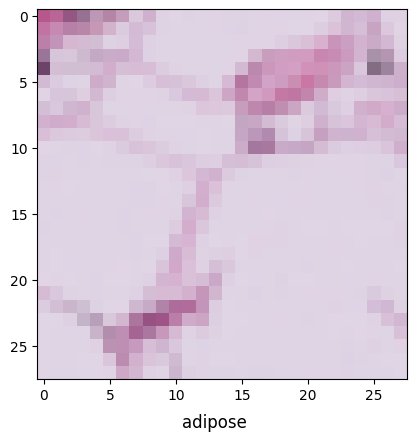

In [9]:
image1 = train_data[0,:,:,:]
plt.imshow(image1)
plt.figtext(0.5, 0.01, label_dict[label1[0]], wrap=True, horizontalalignment='center', fontsize=12)

We can look at each channel individually if we wish, by just plotting one of the layers:

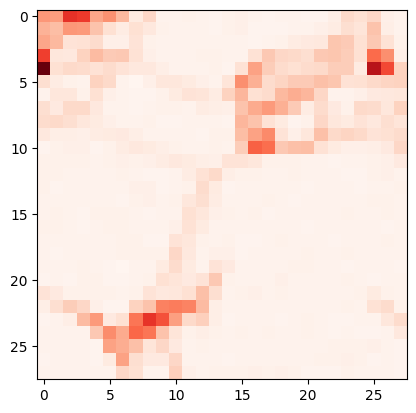

In [10]:
plt.imshow(train_data[0,:,:,0],cmap='Reds_r')

## Train using SKlearn

This data is now in a format that can be used for SKlearn models (although there has been no pre-processing, etc).

We have further processed the data here to take the average of the three (R,G,B) channels to output one (grayscale) channel. You may wish to consider whether to use this grayscale image, or the raw RGB in your classifiers.

In [11]:
## use the sum of channels of each image, and reshape the data into a 1-D array (instead of the 2D image array)
train_1d = np.empty((len(train_data), 28*28))
for i in range(len(train_data)):
    train_1d[i,:] = np.reshape(train_data[i,:,:,0] + train_data[i,:,:,1] + train_data[i,:,:,2] , -1)
    
y = train_labels.ravel()

**model training - pseudocode below**

model = MyClassifier()

model.fit(train_1d, y)

In [ ]:
# 数据标准化后训练 Sklearn 分类器
scaler = StandardScaler()
train_1d_scaled = scaler.fit_transform(train_1d)

# 逻辑回归
model_lr = LogisticRegression(max_iter=500, random_state=42)
model_lr.fit(train_1d_scaled, y)

# 随机森林
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(train_1d_scaled, y)

## Classification metrics
The next two cells are commented out template code to see how well it does on the test set. Note that it will not currently work, as the model has not been defined or trained.

In [12]:
# 准备测试集 1D 特征（与训练集一致：三通道求和）
test_1d = np.empty((len(test_data), 28*28))
for i in range(len(test_data)):
    test_1d[i,:] = np.reshape(test_data[i,:,:,0] + test_data[i,:,:,1] + test_data[i,:,:,2], -1)
test_1d_scaled = scaler.transform(test_1d)

# 预测并评估
test_label_est_lr = model_lr.predict(test_1d_scaled)
test_label_est_rf = model_rf.predict(test_1d_scaled)

In [13]:
test_labels_flat = test_labels.ravel()
print("=== Logistic Regression ===")
print(classification_report(test_labels_flat, test_label_est_lr, target_names=[label_dict[i] for i in range(5)]))
print("=== Random Forest ===")
print(classification_report(test_labels_flat, test_label_est_rf, target_names=[label_dict[i] for i in range(5)]))

# Data format for pytorch
To train a model using Pytorch, we need to convert our data into tensors. We can think of tensor as a multidimensional array. We use tensors, rather than an np.array, as the data type is optimised for GPUs.

It is a bit fiddly to convert the data, so we've done it for you below (note that this is overwriting the variables used previously). 

We've also copied across the CNN similar to the one used in the labs previously to make your life slightly easier.

We have only used a training dataset below, we have not split the training data into a validation and training dataset for you. 

In [14]:
def torch_format_data(data_name, label_name, device):
    t_data = data_name
    t_data = np.mean(t_data, -1)/256
    t_data = np.expand_dims(t_data,1)
    labels = label_name
    labels = labels.squeeze(1)
    
    t_data = torch.tensor(t_data)
    labels = torch.tensor(labels, dtype=torch.long, device=device)
    dataset = torch.utils.data.TensorDataset(t_data, labels)
    return dataset

In [15]:
train_set = torch_format_data(train_data, train_labels, device)
test_set = torch_format_data(test_data, test_labels, device)

In [16]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv2d(
                in_channels=1,              
                out_channels=16,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        )
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16, 32, 5, 1, 2),     
            nn.ReLU(),                      
            nn.MaxPool2d(2),                
        )
        # fully connected layer, output 5 classes (adipose, lymphocytes, normal mucosa, stroma, adenocarcinoma)
        self.out = nn.Linear(32 * 7 * 7, 5)
            

        
    def forward(self, x):
        x = self.conv1(x.float())
        x = self.conv2(x)
        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)       
        output = self.out(x)
        return output, x    # return x for visualization

In [17]:
def train(num_epochs, cnn, loaders):
    
    # this sets the model mode - (i.e. layers like dropout, batchnorm etc behave differently during training compared to testing)
    # note that this function was not defined explicitly in CNN, but because CNN is a type of nn.Module, it inherits some functions
    # from the more general nn class.
    cnn.train()
        
    # Train the model
    total_step = len(loaders['train'])
        
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(loaders['train']):
       
            b_x = images.to(device)
            b_y = labels
            
            output = cnn(b_x)[0]               
            loss = loss_func(output, b_y)
            
            # clear gradients for this training step   
            optimizer.zero_grad()           
            
            # backpropagation, compute gradients 
            loss.backward()    
            # apply gradients             
            optimizer.step()                
            
            if (i+1) % 100 == 0:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                       .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))
            pass     
        pass
    pass

In [18]:
cnn = CNN().to(device)
loss_func = nn.CrossEntropyLoss()   
from torch import optim
optimizer = optim.Adam(cnn.parameters(), lr = 0.001)


loaders = {
    'train' : DataLoader(train_set, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
    
    'test'  : DataLoader(test_set, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
}

In [19]:
num_epochs = 10  # 增加轮数以提升测试准确率

train(num_epochs, cnn, loaders)

Epoch [1/1], Step [100/555], Loss: 1.0718
Epoch [1/1], Step [200/555], Loss: 0.8412
Epoch [1/1], Step [300/555], Loss: 0.7804
Epoch [1/1], Step [400/555], Loss: 0.8227
Epoch [1/1], Step [500/555], Loss: 1.1631


In [20]:
def test(cnn):
    # Test the model
    cnn.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in loaders['test']:
            test_output, last_layer = cnn(images.to(device)) ## this runs the trained cnn. Note from the cnn class, test_output gives the model output (10 x 1 values), and last_layer gives the inputs into the last layer
            ## torch.max finds the highest value of test_output. the [0] array element returns the maximum value, the [1] element
            ## gives the index of that element. squeeze reshapes the data from a nx1 array into a list
            pred_y = torch.max(test_output, 1)[1].data.squeeze() 
            
            correct += (pred_y == labels).sum().item()
            total += float(labels.size(0))
            
        pass
        accuracy = correct / total
        print('Test Accuracy of the model on the test images: %.3f' % accuracy)
    
    pass

In [21]:
test(cnn)

Test Accuracy of the model on the test images: 0.714


In [ ]:
# CNN 在测试集上的详细分类报告
cnn.eval()
cnn_preds, cnn_labels_list = [], []
with torch.no_grad():
    for images, labels in loaders['test']:
        test_output, _ = cnn(images.to(device))
        pred_y = torch.max(test_output, 1)[1].cpu().numpy()
        cnn_preds.extend(pred_y)
        cnn_labels_list.extend(labels.cpu().numpy())
print("=== CNN ===")
print(classification_report(cnn_labels_list, cnn_preds, target_names=[label_dict[i] for i in range(5)]))